https://www.kaggle.com/datasets/aczy156/software-defect-prediction-nasa?resource=download

## Dataset KC1 - Software Defect Prediction

**Descripción:** KC1 es un sistema C++ que implementa gestión de almacenamiento para recibir y procesar datos desde tierra. Contiene 2,109 módulos con 326 (15.45%) defectuosos y 1,783 (84.54%) no defectuosos.

**Fuente:** NASA Metrics Data Program (http://mdp.ivv.nasa.gov)

---

## Descripción de Variables

### Métricas de Líneas de Código (LOC)
1. **loc**: Conteo de líneas de código de McCabe
2. **lOCode**: Líneas de código ejecutable (Halstead)
3. **lOComment**: Líneas de comentarios
4. **lOBlank**: Líneas en blanco
5. **lOCodeAndComment**: Líneas que contienen código y comentarios

### Métricas de Complejidad de McCabe
6. **v(g)**: Complejidad ciclomática - número de caminos linealmente independientes
7. **ev(g)**: Complejidad esencial - grado de estructuración del código
8. **iv(g)**: Complejidad de diseño - refleja los patrones de llamada entre módulos
9. **branchCount**: Número de bifurcaciones del grafo de flujo

### Métricas Base de Halstead
10. **uniq_Op**: Número de operadores únicos (μ1)
11. **uniq_Opnd**: Número de operandos únicos (μ2)
12. **total_Op**: Total de ocurrencias de operadores (N1)
13. **total_Opnd**: Total de ocurrencias de operandos (N2)
14. **n**: Longitud total = N1 + N2

### Métricas Derivadas de Halstead
15. **v**: Volumen - número de comparaciones mentales necesarias (N * log2(μ))
16. **l**: Longitud del programa
17. **d**: Dificultad del programa
18. **i**: Inteligencia del programa
19. **e**: Esfuerzo para escribir el programa
20. **b**: Estimación de errores
21. **t**: Tiempo estimado para programar (en segundos/18)

### Variable Objetivo
22. **Defective**: Indica si el módulo tiene defectos reportados (true/false)

In [1]:
import pandas as pd
from scipy.io import arff

# Load the ARFF file
data, meta = arff.loadarff('KC1.arff')

# Convert the record array to a pandas DataFrame
df = pd.DataFrame(data)

# Decode byte strings in object columns (if necessary)
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].str.decode('utf-8')

df.head()

,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,...,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,class
0,1.1,1.4,1.4,1.4,1.3,1.30,1.30,1.30,1.30,1.30,...,2.0,2.0,2.0,2.0,1.2,1.2,1.2,1.2,1.4,false
1,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.00,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,true
2,83.0,11.0,1.0,11.0,171.0,927.89,0.04,23.04,40.27,21378.61,...,65.0,10.0,6.0,0.0,18.0,25.0,107.0,64.0,21.0,true
3,46.0,8.0,6.0,8.0,141.0,769.78,0.07,14.86,51.81,11436.73,...,37.0,2.0,5.0,0.0,16.0,28.0,89.0,52.0,15.0,true
4,25.0,3.0,1.0,3.0,58.0,254.75,0.11,9.35,27.25,2381.95,...,21.0,0.0,2.0,0.0,11.0,10.0,41.0,17.0,5.0,true


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2109 entries, 0 to 2108
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   loc                2109 non-null   float64
 1   v(g)               2109 non-null   float64
 2   ev(g)              2109 non-null   float64
 3   iv(g)              2109 non-null   float64
 4   n                  2109 non-null   float64
 5   v                  2109 non-null   float64
 6   l                  2109 non-null   float64
 7   d                  2109 non-null   float64
 8   i                  2109 non-null   float64
 9   e                  2109 non-null   float64
 10  b                  2109 non-null   float64
 11  t                  2109 non-null   float64
 12  lOCode             2109 non-null   float64
 13  lOComment          2109 non-null   float64
 14  lOBlank            2109 non-null   float64
 15  locCodeAndComment  2109 non-null   float64
 16  uniq_Op            2109 

In [3]:
df.shape

(2109, 22)

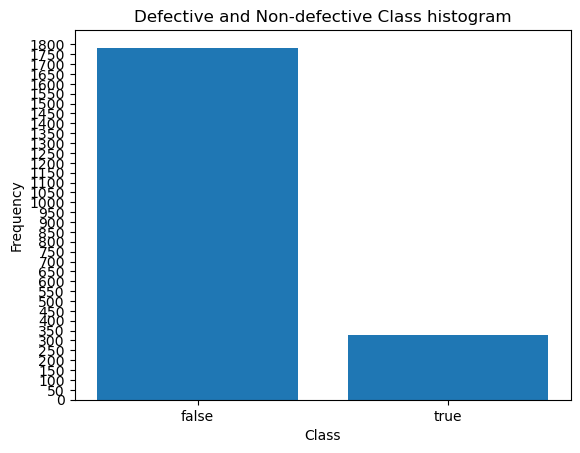

In [5]:
#Defective and Non-defective Class histogram
import matplotlib.pyplot as plt

# Count the occurrences of each class
class_counts = df['class'].value_counts()

# Plot the histogram
plt.bar(class_counts.index, class_counts.values)
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.title('Defective and Non-defective Class histogram')
plt.xticks(rotation=0)
# show more numbers in frequency (y axis)
plt.gca().set_yticks(range(0, class_counts.max() + 50, 50))
# show the grid
# plt.grid(axis='y')
plt.show()

In [ ]:
class_counts

<Axes: xlabel='class', ylabel='loc'>

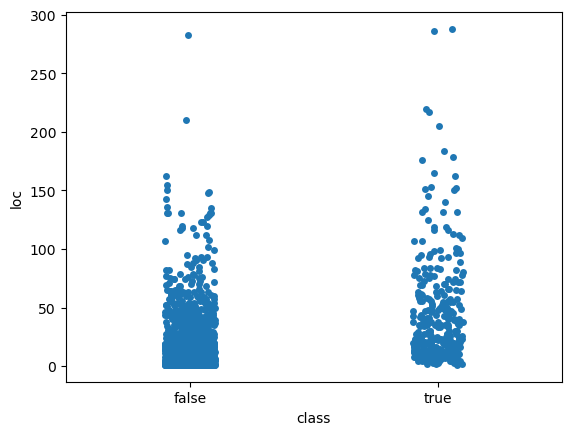

In [7]:
# Dispersion plot of class Defective
import seaborn as sns

sns.stripplot(x='class', y='loc', data=df, jitter=True)

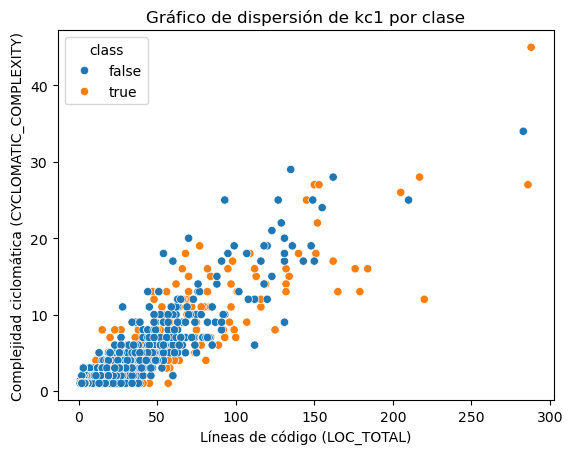

In [8]:
# Gráfico de dispersión de métricas de software por clase
sns.scatterplot(x='loc', y='v(g)', hue='class', data=df)

# Añadir títulos y etiquetas
plt.title('Gráfico de dispersión de kc1 por clase')
plt.xlabel('Líneas de código (LOC_TOTAL)')
plt.ylabel('Complejidad ciclomática (CYCLOMATIC_COMPLEXITY)')
plt.show()